In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, shutil
import cv2
import matplotlib.image as mpimg
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')

In [16]:
#Dataset
import zipfile

z = zipfile.ZipFile('archive.zip')
z.extractall()

In [17]:
folder = 'brain_tumor_dataset/yes/'
count = 1

for filename in os.listdir(folder):
    source = folder + filename
    destination = folder + "Y_" + str(count) + ".jpg"
    os.rename(source,destination)
    count+=1
print("All files are renamed in the yes dir.")    

All files are renamed in the yes dir.


In [18]:
folder = 'brain_tumor_dataset/no/'
count = 1

for filename in os.listdir(folder):
    source = folder + filename
    destination = folder + "N_" + str(count) + ".jpg"
    os.rename(source,destination)
    count+=1
print("All files are renamed in the no dir.") 

All files are renamed in the no dir.


In [20]:
#EDA(Exploratory Data Analysis)

In [19]:
listyes = os.listdir("brain_tumor_dataset/yes/")
number_files_yes = len(listyes)
print(number_files_yes)

listno = os.listdir("brain_tumor_dataset/no/")
number_files_no = len(listno)
print(number_files_no)

155
98


In [ ]:
#Plot

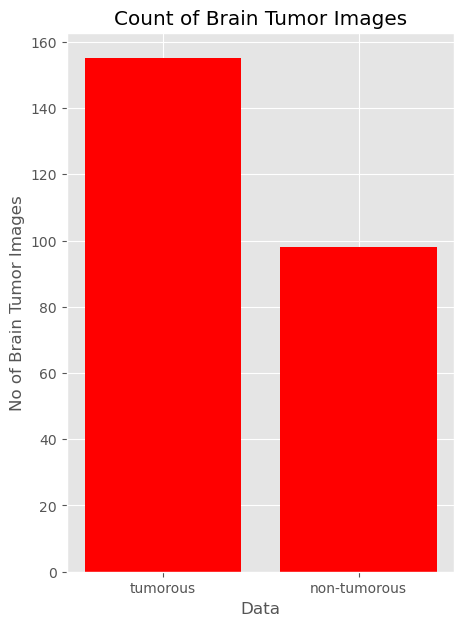

In [29]:
data = {'tumorous': number_files_yes, 'non-tumorous': number_files_no}

typex = data.keys()
values = data.values()

plt.figure(figsize=(5,7))

plt.bar(typex, values, color="red")

plt.xlabel("Data")
plt.ylabel("No of Brain Tumor Images")
plt.title("Count of Brain Tumor Images")
plt.show()

In [ ]:
#Data Augmentation
#155(61%), 98(39%)
# imbalance 

In [32]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/351.2 MB 1.4 MB/s eta 0:04:04
   ---------------------------------------- 1.3/351.2 MB 1.7 MB/s eta 0:03:26
   ---------------------------------------- 1.8/351.2 MB 1.9 MB/s eta 0:03:06
   ---------------------------------------- 2.4/351.2 MB 2.1 MB/s eta 0:02:47
   ---------------------------------------- 2.4/351.2 MB 2.1 MB/s eta 0:02:47
   ---------------------------------------- 2.6/351.2 MB 1.6 MB/s eta 0:03:40
   ---------------------------------------- 3.1/351.2 MB 1.8 MB/s eta 0:03:13
   -------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [34]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


In [35]:
def timing(sec_elapsed):
    h = int(sec_elapsed / (60*60))
    m = int(sec_elapsed % (60*60) / 60)
    s = sec_elapsed % 60

    return f"{h}:{m}:{s}"

In [37]:
def augmented_data(file_dir, n_generated_samples, save_to_dir):
    data_gen = ImageDataGenerator(rotation_range=10,
                                  width_shift_range=0.1,
                                  height_shift_range=0.1,
                                  brightness_range=(0.3, 1.0),
                                  horizontal_flip=True,
                                  vertical_flip=True,
                                  fill_mode='nearest')
    for filename in os.listdir(file_dir):
        image = cv2.imread(file_dir + '/' +filename)
        image = image.reshape((1,) + image.shape)
        save_prefix = 'aug' + filename[:-4]
        i=0
        for batch in data_gen.flow(x = image, batch_size = 1, save_to_dir = save_to_dir, save_prefix = save_prefix, save_format = "jpg"):
            i+=1
            if i>n_generated_samples:
                break


In [39]:
import time
start_time = time.time()

yes_path = 'brain_tumor_dataset/yes'
no_path = 'brain_tumor_dataset/no'

augmented_data_path = 'augmented_data/'

augmented_data(file_dir = yes_path, n_generated_samples=6, save_to_dir=augmented_data_path+'yes')
augmented_data(file_dir = no_path, n_generated_samples=9, save_to_dir=augmented_data_path+'no')

end_time = time.time()
excution_time = end_time - start_time
print(timing(excution_time))

0:1:33.99162483215332


In [42]:
def data_summary(main_path):
    yes_path = "augmented_data/yes"
    no_path = "augmented_data/no"

    n_pos = len(os.listdir(yes_path))
    n_neg = len(os.listdir(no_path))

    n = (n_pos + n_neg)

    pos_per = (n_pos*100)/n
    neg_per = (n_neg*100)/n

    print(f"Number of sample: {n}")
    print(f"{n_pos}Number of positive sample in percentage: {pos_per}%")
    print(f"{n_neg} Number of Negative sample in percentage: {neg_per}%")

In [43]:
data_summary(augmented_data_path)

Number of sample: 2064
1085Number of positive sample in percentage: 52.56782945736434%
979 Number of Negative sample in percentage: 47.43217054263566%


In [45]:
listyes = os.listdir("augmented_data/yes/")
number_files_yes = len(listyes)
print(number_files_yes)

listno = os.listdir("augmented_data/no/")
number_files_no = len(listno)
print(number_files_no)

1085
979


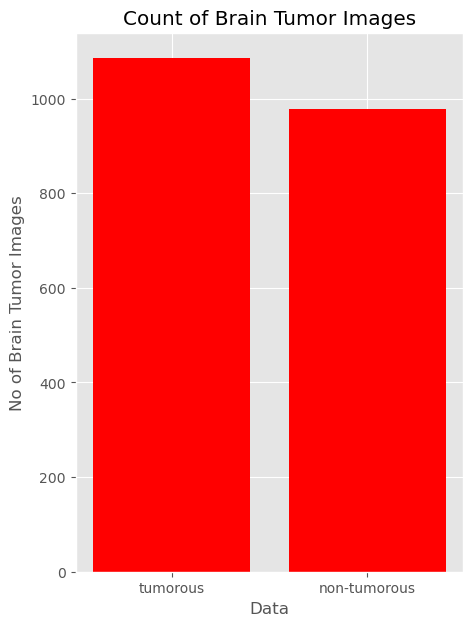

In [46]:
data = {'tumorous': number_files_yes, 'non-tumorous': number_files_no}

typex = data.keys()
values = data.values()

plt.figure(figsize=(5,7))

plt.bar(typex, values, color="red")

plt.xlabel("Data")
plt.ylabel("No of Brain Tumor Images")
plt.title("Count of Brain Tumor Images")
plt.show()

In [ ]:
#Data Preprocessing

In [ ]:
# Convert BGR TO GRAY
# GaussionBlur
# Threshold
# Erode
# Dilate
# Find Contours

In [ ]:
import imutils
def crop_brain_tumor(image, plot=False):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5,5), 0)

    thres = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thres= cv2.erode(thres, None,iterations=2)
    thres = cv2.dilate(thres,None,iterations=2)

    cnts = cv2.findContours(thres.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutil